In [1]:
# Customer Segmentation Using K-Means Clustering
# Part 1: Creating and Loading the Customer Dataset

import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Generate synthetic customer data
n_customers = 200

data = pd.DataFrame({
    "Customer_ID": range(1, n_customers + 1),
    "Age": np.random.randint(18, 70, n_customers),
    "Annual_Income": np.random.randint(20000, 150000, n_customers),
    "Spending_Score": np.random.randint(1, 101, n_customers)
})

# Display the first five rows
data.head()

,Customer_ID,Age,Annual_Income,Spending_Score
0,1,56,78053,8
1,2,69,41959,27
2,3,46,25530,27
3,4,32,114856,98
4,5,60,139101,21


### Key Observation

The dataset contains customer information including age, annual income, and spending score.

These features will be used to identify groups of customers with similar characteristics using K-Means clustering.

In [3]:
# Part 2: Dataset Inspection and Exploratory Analysis

# Display the dataset shape
print("Dataset Shape:", data.shape)

# Display information about the dataset
print("\nDataset Information:")
data.info()

# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Display summary statistics
print("\nSummary Statistics:")
display(data.describe())

Dataset Shape: (200, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer_ID     200 non-null    int64
 1   Age             200 non-null    int64
 2   Annual_Income   200 non-null    int64
 3   Spending_Score  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB

Missing Values:
Customer_ID       0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

Summary Statistics:


,Customer_ID,Age,Annual_Income,Spending_Score
count,200.000000,200.00000,200.00000,200.000000
mean,100.500000,43.42500,85957.25000,51.295000
std,57.879185,14.94191,38605.01739,29.926845
min,1.000000,18.00000,20854.00000,1.000000
25%,50.750000,31.00000,54740.00000,24.000000
50%,100.500000,43.50000,86931.00000,52.000000
75%,150.250000,56.00000,118200.00000,76.000000
max,200.000000,69.00000,148391.00000,100.000000


### Key Observation

The dataset contains customer information with numerical features including age, annual income, and spending score.

The data quality analysis checks for missing values and provides summary statistics to better understand the range and distribution of each customer characteristic.

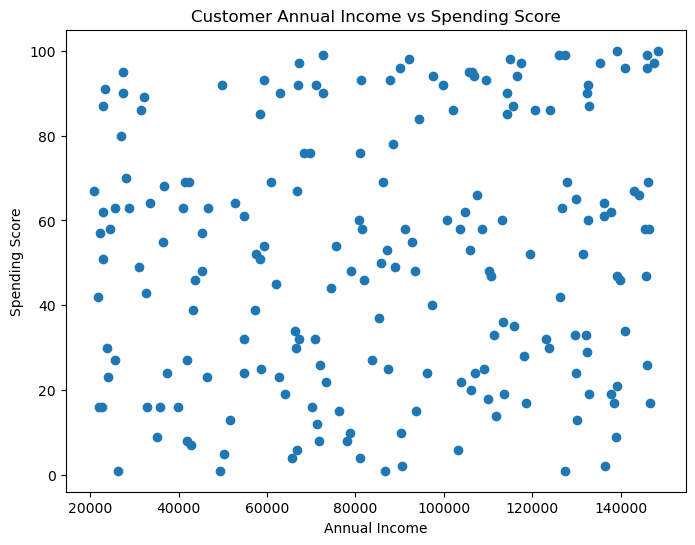

In [5]:
# Part 3: Customer Data Visualisation

import matplotlib.pyplot as plt

# Create scatter plot for Annual Income and Spending Score
plt.figure(figsize=(8, 6))

plt.scatter(
    data["Annual_Income"],
    data["Spending_Score"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Annual Income vs Spending Score")

plt.show()

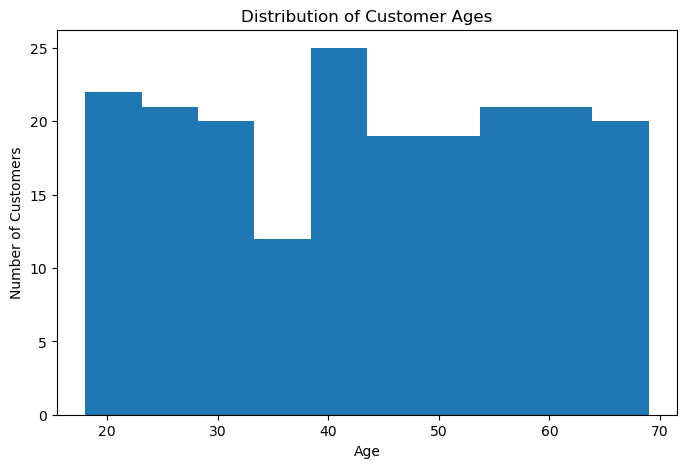

In [6]:
# Distribution of customer ages

plt.figure(figsize=(8, 5))

plt.hist(
    data["Age"],
    bins=10
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Ages")

plt.show()

### Key Observation

The visualisations provide an overview of the customer characteristics within the dataset.

The scatter plot shows the relationship between annual income and spending score, while the histogram illustrates the distribution of customer ages. These patterns will be explored further using clustering techniques.

In [7]:
# Part 4: Preparing Features for Clustering

# Select relevant customer features
X = data[
    [
        "Age",
        "Annual_Income",
        "Spending_Score"
    ]
]

# Display the selected features
X.head()

,Age,Annual_Income,Spending_Score
0,56,78053,8
1,69,41959,27
2,46,25530,27
3,32,114856,98
4,60,139101,21


### Key Observation

Customer ID is excluded from the clustering process because it is only used to identify individual customers.

Age, annual income, and spending score will be used as the main features to identify groups of customers with similar characteristics.

In [8]:
# Part 5: Feature Scaling

from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Scale the customer features
X_scaled = scaler.fit_transform(X)

# Display the scaled data
X_scaled[:5]

array([[ 0.84370444, -0.2052605 , -1.45032478],
       [ 1.71592374, -1.14256288, -0.81385011],
       [ 0.17276652, -1.56919725, -0.81385011],
       [-0.76654658,  0.75045346,  1.56455524],
       [ 1.11207961,  1.38005662, -1.01484211]])

### Key Observation

Feature scaling standardises the numerical variables before clustering.

This is important for K-Means because the algorithm uses distances to group similar customers. Without scaling, features with larger numerical values, such as annual income, could have a greater influence on the clustering process.

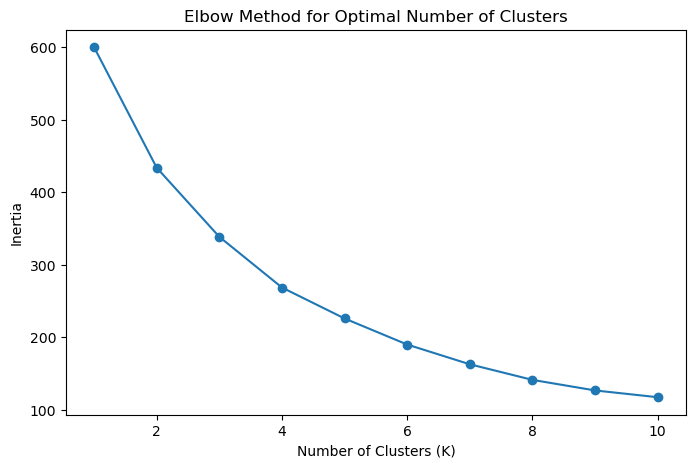

In [9]:
# Part 6: Finding the Optimal Number of Clusters

from sklearn.cluster import KMeans

# Store the inertia values
inertia_values = []

# Test different numbers of clusters
k_values = range(1, 11)

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    # Store the inertia value
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.show()

### Key Observation

The Elbow Method evaluates how the clustering inertia changes as the number of clusters increases.

A suitable number of clusters can often be identified at the point where the decrease in inertia begins to slow down, creating an "elbow" shape in the graph. This value will be used to develop the final K-Means clustering model.

In [10]:
# Part 7: Apply the K-Means Clustering Model

# Create the K-Means model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Train the model and assign cluster labels
data["Cluster"] = kmeans.fit_predict(X_scaled)

# Display the first five rows with cluster assignments
data.head()

,Customer_ID,Age,Annual_Income,Spending_Score,Cluster
0,1,56,78053,8,1
1,2,69,41959,27,1
2,3,46,25530,27,1
3,4,32,114856,98,2
4,5,60,139101,21,1


In [11]:
# Count customers in each cluster

cluster_counts = data["Cluster"].value_counts().sort_index()

print("Number of Customers in Each Cluster:")
print(cluster_counts)

Number of Customers in Each Cluster:
Cluster
0    72
1    65
2    63
Name: count, dtype: int64


### Key Observation

The K-Means algorithm successfully grouped customers into three clusters based on their age, annual income, and spending score.

Each customer has been assigned a cluster label representing the group with the most similar customer characteristics.

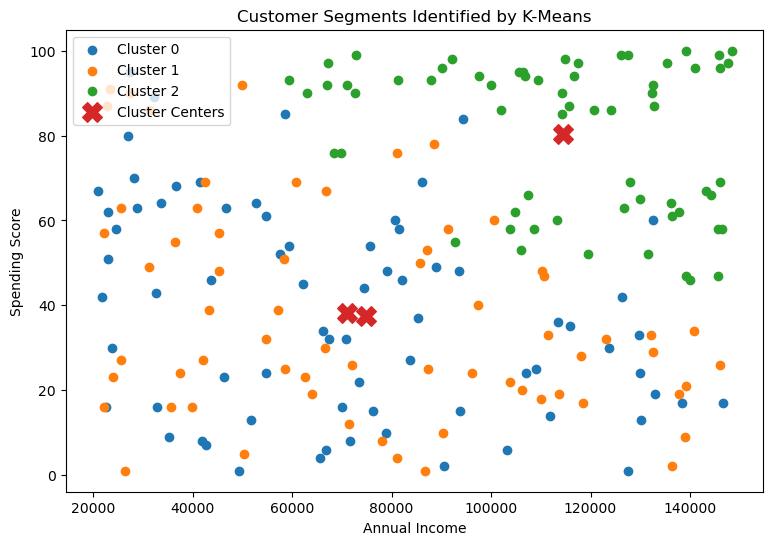

In [12]:
# Part 8: Visualising Customer Clusters

plt.figure(figsize=(9, 6))

# Plot each cluster separately
for cluster in sorted(data["Cluster"].unique()):
    
    cluster_data = data[data["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["Annual_Income"],
        cluster_data["Spending_Score"],
        label=f"Cluster {cluster}"
    )

# Plot cluster centres
centers = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centers[:, 1],
    centers[:, 2],
    marker="X",
    s=200,
    label="Cluster Centers"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments Identified by K-Means")
plt.legend()

plt.show()

### Key Observation

The visualisation shows how customers have been grouped into different clusters based on their annual income and spending score.

Customers within the same cluster have similar characteristics, while customers in different clusters show different patterns. The cluster centres represent the central position of each customer segment.

In [13]:
# Part 9: Customer Segment Analysis

# Calculate the average characteristics of each cluster
cluster_summary = data.groupby("Cluster").agg({
    "Age": "mean",
    "Annual_Income": "mean",
    "Spending_Score": "mean"
}).round(2)

# Add the number of customers in each cluster
cluster_summary["Number_of_Customers"] = (
    data.groupby("Cluster").size()
)

# Display the cluster summary
display(cluster_summary)

,Age,Annual_Income,Spending_Score,Number_of_Customers
Cluster,,,,
0,29.17,70989.04,38.25,72
1,57.25,74839.97,37.51,65
2,45.46,114533.98,80.43,63


### Key Observation

The cluster summary provides the average age, annual income, and spending score for customers in each segment.

Comparing these values helps identify the unique characteristics of each customer group. For example, some clusters may contain customers with higher incomes and spending scores, while others may represent customers with different spending behaviours.

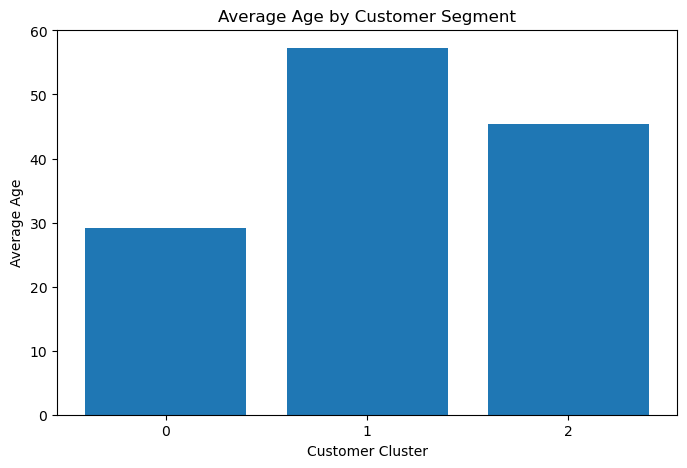

In [14]:
# Part 10: Compare Customer Segments

# Reset the index so Cluster becomes a column
segment_data = cluster_summary.reset_index()

# Compare average age
plt.figure(figsize=(8, 5))

plt.bar(
    segment_data["Cluster"].astype(str),
    segment_data["Age"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Age")
plt.title("Average Age by Customer Segment")

plt.show()

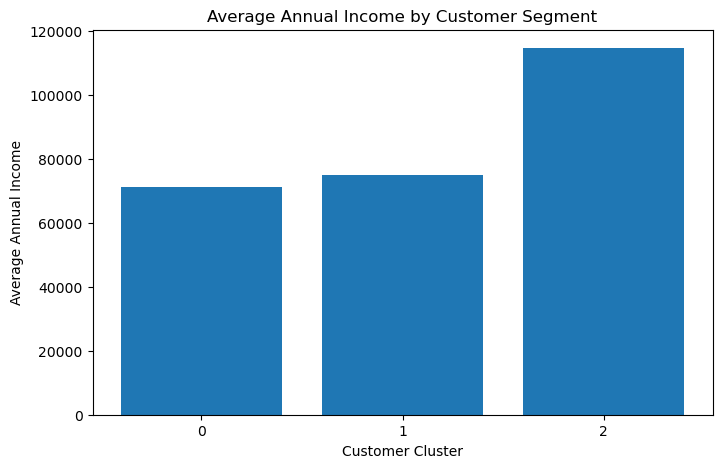

In [15]:
# Compare average annual income

plt.figure(figsize=(8, 5))

plt.bar(
    segment_data["Cluster"].astype(str),
    segment_data["Annual_Income"]
)

plt.xlabel("Customer Cluster")
plt.ylabel("Average Annual Income")
plt.title("Average Annual Income by Customer Segment")

plt.show()

### Key Observation

The visual comparisons highlight the differences between the customer segments.

Each cluster has different average characteristics in terms of age, annual income, and spending behaviour. These differences can help businesses understand the characteristics of their customer groups and develop more targeted strategies.

In [16]:
# Part 11: Business Insights and Customer Segment Interpretation

for cluster in cluster_summary.index:
    
    age = cluster_summary.loc[cluster, "Age"]
    income = cluster_summary.loc[cluster, "Annual_Income"]
    spending = cluster_summary.loc[cluster, "Spending_Score"]
    
    print(f"\nCluster {cluster}")
    print(f"Average Age: {age}")
    print(f"Average Annual Income: ${income:,.2f}")
    print(f"Average Spending Score: {spending}")


Cluster 0
Average Age: 29.17
Average Annual Income: $70,989.04
Average Spending Score: 38.25

Cluster 1
Average Age: 57.25
Average Annual Income: $74,839.97
Average Spending Score: 37.51

Cluster 2
Average Age: 45.46
Average Annual Income: $114,533.98
Average Spending Score: 80.43


## Business Insights

The customer segmentation analysis identifies groups of customers with different demographic and spending characteristics.

Businesses can use these customer segments to develop more targeted strategies. For example:

- Customers with high income and high spending scores may represent valuable customers who could benefit from loyalty programs or premium product recommendations.
- Customers with high income but lower spending scores may represent an opportunity for targeted marketing campaigns.
- Customers with lower income and lower spending scores may respond better to affordable products, discounts, or promotional offers.

These interpretations are based on the characteristics of the clusters identified by the K-Means algorithm.

## Part 12: Conclusion and Project Summary

### Project Summary

This project applied K-Means clustering to identify groups of customers with similar characteristics.

The analysis began by creating and exploring the customer dataset. The data was inspected for its structure, missing values, and general characteristics. Visualisations were then used to explore customer age, annual income, and spending behaviour.

The relevant features were selected and scaled before applying the K-Means clustering algorithm. The Elbow Method was used to investigate a suitable number of customer clusters.

After applying K-Means clustering, the customer segments were visualised and analysed based on their average age, annual income, and spending score. The characteristics of each segment were compared to identify differences between customer groups.

### Business Value

Customer segmentation can help businesses better understand their customers and develop more targeted strategies.

Different customer groups may respond differently to marketing campaigns, promotions, loyalty programs, and product recommendations. Understanding these differences can help businesses make more informed decisions.

### Future Improvements

Potential improvements for future work include:

- Using a real-world customer dataset.
- Testing different numbers of clusters.
- Applying additional clustering algorithms.
- Including more customer-related features.
- Using advanced visualisation techniques.
- Evaluating clustering quality using additional metrics.

### Final Conclusion

This project demonstrates how unsupervised machine learning can be used to identify meaningful patterns within customer data.

K-Means clustering successfully groups customers based on similar characteristics without requiring predefined target labels. The results provide useful insights that could support customer-focused business and marketing strategies.